# 07. Missing-Data Robustness Sweep

## 0. Setup

In [1]:
import csv
import random
import re
import json
import time
import math
import copy
import traceback
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
from PIL import Image
import torch
import torch.nn as nn
import torchvision.transforms.functional as TF
from torchvision import transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.utils.checkpoint import checkpoint
from sklearn.metrics import f1_score, roc_auc_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

MANIFEST = Path('~/Desktop/convscript/Code/Manifest/manifests/master_manifest.csv').expanduser()
ROOT     = Path('~/Desktop/Thesis/TR-6').expanduser()
GAS_NORM = Path('~/Desktop/convscript/Code/Manifest/GasNorm/gas_norm_stats.json').expanduser()
RUNS     = Path('~/Desktop/convscript/runs').expanduser()

DEVICE = (
    'mps'  if torch.backends.mps.is_available() else
    'cuda' if torch.cuda.is_available()          else
    'cpu'
)
print(f'Device: {DEVICE}')

ABLATION_CKPT_DIR = RUNS / "05_ablation_study"
ROBUST_OUT = RUNS / "08_missing_data_robustness"
ROBUST_OUT.mkdir(parents=True, exist_ok=True)


Device: mps


## Data pipeline

In [2]:
FRUIT_LIST   = ['Banana', 'Carrot', 'Guava', 'Indian_Gooseberry', 'Mango', 'Tomato']
FRUIT_TO_IDX = {f: i for i, f in enumerate(FRUIT_LIST)}
SESSION_TO_IDX = {'morning': 0, 'afternoon': 1, 'evening': 2}
LABEL_TO_IDX   = {'not_spoiled': 0, 'spoiled': 1}
IMAGE_SIZE     = 224
IMAGENET_MEAN  = [0.485, 0.456, 0.406]
IMAGENET_STD   = [0.229, 0.224, 0.225]
SESSION_HOUR_BUCKETS = {'morning': (5, 11), 'afternoon': (12, 16), 'evening': (16, 19)}
IR_PATTERN   = re.compile(r'(\d{8})_(\d{6})_([\d.]+)C_([\d.]+)C\.jpg$', re.IGNORECASE)
SRGB_PATTERN = re.compile(r'^(\d{8})_(\d{6})[^/]*\.jpg$', re.IGNORECASE)
NUM_FRUITS   = len(FRUIT_TO_IDX)
THRESHOLDS_TO_SWEEP = [t / 100 for t in range(10, 91)]


def safe_float(val, default=0.0):
    try:
        return float(val)
    except Exception:
        return default


def hour_to_session(hour):
    for name, (lo, hi) in SESSION_HOUR_BUCKETS.items():
        if lo <= hour < hi:
            return name
    return 'unknown'


def find_ir_folder(base):
    for name in ['IR_fusion_images', 'IR_Fusion_images', 'ir_fusion_images']:
        p = base / name
        if p.exists():
            return p
    return base / 'IR_fusion_images'


def group_images_by_session(folder, pattern):
    result = defaultdict(lambda: defaultdict(list))
    if not folder.exists():
        return {}
    for f in sorted(folder.iterdir()):
        m = pattern.search(f.name)
        if not m:
            continue
        session = hour_to_session(int(m.group(2)[:2]))
        if session != 'unknown':
            result[m.group(1)][session].append(f)
    return dict(result)


def load_image(path, transform):
    return transform(Image.open(path).convert('RGB'))


def get_rgb_transform(train: bool):
    if train:
        return transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.RandomHorizontalFlip(), transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    return transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])


def get_ir_transform(train: bool):
    if train:
        return transforms.Compose([
            transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
            transforms.RandomHorizontalFlip(), transforms.RandomRotation(15),
            transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    return transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])


In [3]:
class TrimodalDataset(Dataset):
    def __init__(self, manifest_path, root, train=True, modality_dropout_prob=0.3,
                 exclude_flagged=True, split=None, gas_norm_stats_path=None,
                 cache_images=True, shared_pixel_cache=None, gas_only=False):
        self.root = Path(root); self.train = train; self.modality_dropout_prob = modality_dropout_prob
        self.rgb_transform = get_rgb_transform(train); self.ir_transform = get_ir_transform(train)
        self.gas_norm_stats = None
        if gas_norm_stats_path:
            with open(gas_norm_stats_path) as f:
                self.gas_norm_stats = json.load(f)['stats']
            print(f'Gas norm stats loaded from {gas_norm_stats_path}')
        with open(manifest_path, newline='') as f:
            all_rows = list(csv.DictReader(f))
        if exclude_flagged:
            all_rows = [r for r in all_rows if r.get('exclude', '').strip().lower() != 'true']
        if split:
            all_rows = [r for r in all_rows if r.get('split', '').strip().lower() == split.lower()]
        self.samples = []; self._build_samples(all_rows)
        self.gas_only = gas_only; self._image_cache = {}
        if not gas_only:
            self._build_image_index()
        self._pixel_cache = {}
        if not gas_only:
            if shared_pixel_cache is not None:
                self._pixel_cache = shared_pixel_cache
                print(f'  Using shared image cache ({len(self._pixel_cache)} images).', flush=True)
            elif cache_images:
                self._warmup_pixel_cache()
        print(f'TrimodalDataset: {len(self.samples)} sessions '
              f'({"train" if train else "val/test"}, split={split})')

    def _build_samples(self, rows):
        for row in rows:
            fruit = row['fruit']; label = row['label']; date_str = row['actual_date']
            global_day = int(row['corrected_day_index'])
            days_until = safe_float(row.get('days_until_spoilage', ''), default=-1.0)
            for session in ['morning', 'afternoon', 'evening']:
                si = SESSION_TO_IDX[session]
                ir_avail = safe_float(row.get(f'ir_{session}_count', 0)) > 0
                ir_tmin = safe_float(row.get(f'ir_{session}_tmin', ''), 0.0)
                ir_tmax = safe_float(row.get(f'ir_{session}_tmax', ''), 0.0)
                ir_trange = safe_float(row.get(f'ir_{session}_trange', ''), 0.0)
                srgb_avail = safe_float(row.get(f'srgb_{session}_count', 0)) > 0
                gas_avail = row.get(f'methane_{session}_present', '').strip().upper() == 'TRUE'
                mean_ppm = safe_float(row.get(f'methane_{session}_ppm', ''), 0.0)
                std_ppm = safe_float(row.get(f'methane_{session}_std', ''), 0.0)
                left_ppm = safe_float(row.get(f'methane_{session}_left', ''), 0.0)
                right_ppm = safe_float(row.get(f'methane_{session}_right', ''), 0.0)
                if not ir_avail and not srgb_avail and not gas_avail:
                    continue
                self.samples.append({'fruit': fruit, 'label': label, 'actual_date': date_str,
                    'corrected_day_index': global_day, 'session': session, 'session_idx': si,
                    'fruit_idx': FRUIT_TO_IDX.get(fruit, 0), 'label_idx': LABEL_TO_IDX.get(label, 0),
                    'days_until_spoilage': days_until, 'ir_tmin': ir_tmin, 'ir_tmax': ir_tmax,
                    'ir_trange': ir_trange, 'gas_mean': mean_ppm, 'gas_std': std_ppm,
                    'gas_left': left_ppm, 'gas_right': right_ppm, 'gas_asym': abs(left_ppm - right_ppm),
                    'rgb_available': srgb_avail, 'ir_available': ir_avail, 'gas_available': gas_avail})

    def _build_image_index(self):
        label_map = {'not_spoiled': 'Not_spoiled', 'spoiled': 'Spoiled'}
        for fruit in FRUIT_LIST:
            for lk, lf in label_map.items():
                base = self.root / 'Classified' / fruit / lf
                for d, ss in group_images_by_session(base / 'sRGB_images', SRGB_PATTERN).items():
                    for s, ps in ss.items():
                        self._image_cache.setdefault((fruit, lk, d, s), {'rgb': [], 'ir': []})['rgb'] = ps
                for d, ss in group_images_by_session(find_ir_folder(base), IR_PATTERN).items():
                    for s, ps in ss.items():
                        self._image_cache.setdefault((fruit, lk, d, s), {'rgb': [], 'ir': []})['ir'] = ps
        banana_ir = group_images_by_session(find_ir_folder(self.root / 'Normal' / 'Banana'), IR_PATTERN)
        spoiled_dates = {date for (fr, lb, date, _) in self._image_cache if fr == 'Banana' and lb == 'spoiled'}
        for d, ss in banana_ir.items():
            if d in spoiled_dates:
                for s, ps in ss.items():
                    key = ('Banana', 'spoiled', d, s)
                    self._image_cache.setdefault(key, {'rgb': [], 'ir': []})
                    if not self._image_cache[key].get('ir'):
                        self._image_cache[key]['ir'] = ps

    def _load_cached(self, path, transform):
        cached = self._pixel_cache.get(str(path))
        if cached is not None:
            return transform(Image.fromarray(cached.permute(1, 2, 0).numpy()))
        return load_image(path, transform)

    def _warmup_pixel_cache(self):
        all_paths = set()
        for v in self._image_cache.values():
            all_paths.update(v.get('rgb', [])); all_paths.update(v.get('ir', []))
        total = len(all_paths)
        print(f'  Warming up image cache: {total} images...', flush=True)
        for i, path in enumerate(all_paths):
            if str(path) in self._pixel_cache:
                continue
            try:
                img = self.rgb_transform.transforms[0](Image.open(path).convert('RGB'))
                self._pixel_cache[str(path)] = torch.from_numpy(np.array(img)).permute(2, 0, 1)
            except Exception:
                pass
            if (i + 1) % 500 == 0 or (i + 1) == total:
                mb = sum(t.nbytes for t in self._pixel_cache.values()) / (1024 ** 2)
                print(f'  {i + 1}/{total} cached  ({mb:.0f} MB used)', flush=True)
        print(f'  Cache ready. {len(self._pixel_cache)} images in RAM.', flush=True)

    def _normalize_gas(self, fruit, session, mean_ppm, std_ppm, left_ppm, right_ppm):
        if self.gas_norm_stats is None:
            return mean_ppm, std_ppm, left_ppm, right_ppm
        s = self.gas_norm_stats.get(fruit, {}).get(session, {})

        def norm(val, key):
            st = s.get(key, {'mean': 0., 'std': 1.})
            return (val - st['mean']) / st['std']
        return norm(mean_ppm, 'mean_ppm'), norm(std_ppm, 'std_ppm'), norm(left_ppm, 'left_ppm'), norm(right_ppm, 'right_ppm')

    def _apply_dropout(self, rgb_avail, ir_avail, gas_avail):
        if not self.train:
            return rgb_avail, ir_avail, gas_avail
        while True:
            r = rgb_avail and (random.random() > self.modality_dropout_prob)
            i = ir_avail and (random.random() > self.modality_dropout_prob)
            g = gas_avail and (random.random() > self.modality_dropout_prob)
            if r or i or g:
                return r, i, g

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s = self.samples[idx]
        fruit = s['fruit']; label = s['label']; date_str = s['actual_date']
        session = s['session']; si = s['session_idx']
        rgb_avail, ir_avail, gas_avail = self._apply_dropout(s['rgb_available'], s['ir_available'], s['gas_available'])
        cached = self._image_cache.get((fruit, label, date_str, session), {'rgb': [], 'ir': []})
        if not self.gas_only and rgb_avail and cached['rgb']:
            rgb_tensors = torch.stack([self._load_cached(p, self.rgb_transform) for p in cached['rgb']])
        else:
            rgb_avail = False; rgb_tensors = torch.zeros(1, 3, IMAGE_SIZE, IMAGE_SIZE)
        if not self.gas_only and ir_avail and cached['ir']:
            ir_tensors = torch.stack([self._load_cached(p, self.ir_transform) for p in cached['ir']])
        else:
            ir_avail = False; ir_tensors = torch.zeros(1, 3, IMAGE_SIZE, IMAGE_SIZE)
        ir_scalars = torch.tensor([s['ir_tmin'], s['ir_tmax'], s['ir_trange']], dtype=torch.float32) if ir_avail else torch.zeros(3)
        if gas_avail:
            m, sd, l, r = self._normalize_gas(fruit, session, s['gas_mean'], s['gas_std'], s['gas_left'], s['gas_right'])
            gas = torch.tensor([m, sd, l, r, abs(l - r), float(si) / 2.], dtype=torch.float32)
        else:
            gas = torch.zeros(6)
        return {'rgb_images': rgb_tensors, 'ir_images': ir_tensors, 'ir_scalars': ir_scalars, 'gas': gas,
                'rgb_available': torch.tensor(rgb_avail, dtype=torch.bool),
                'ir_available': torch.tensor(ir_avail, dtype=torch.bool),
                'gas_available': torch.tensor(gas_avail, dtype=torch.bool),
                'fruit_idx': torch.tensor(s['fruit_idx'], dtype=torch.long),
                'session_idx': torch.tensor(si, dtype=torch.long),
                'label': torch.tensor(s['label_idx'], dtype=torch.long),
                'days_until_spoilage': torch.tensor(s['days_until_spoilage'], dtype=torch.float32),
                'fruit': fruit, 'actual_date': date_str, 'corrected_day_index': s['corrected_day_index']}


In [4]:
class DayLevelSequenceDataset(Dataset):
    def __init__(self, manifest_path=MANIFEST, root=ROOT, split="train",
                 gas_norm_stats_path=GAS_NORM, shared_pixel_cache=None):
        base = TrimodalDataset(
            manifest_path, root, train=False, modality_dropout_prob=0.0,
            split=split, gas_norm_stats_path=gas_norm_stats_path, cache_images=True,
            shared_pixel_cache=shared_pixel_cache,
        )
        self._pixel_cache = base._pixel_cache
        print(f"DayLevelSequenceDataset ({split}): wrapping {len(base)} sessions")
        day_groups = defaultdict(list)
        for i in range(len(base)):
            item = base[i]
            key = (item["fruit"], int(item["label"].item()), int(item["corrected_day_index"]))
            day_groups[key].append(item)
        day_entries = {}
        for (fruit, label, day_idx), sessions in day_groups.items():
            sessions.sort(key=lambda s: int(s["session_idx"].item()))
            rgb_img, ir_img = None, None
            for s in sessions:
                if rgb_img is None and bool(s["rgb_available"].item()) and len(s["rgb_images"]) > 0:
                    rgb_img = s["rgb_images"][0]
                if ir_img is None and bool(s["ir_available"].item()) and len(s["ir_images"]) > 0:
                    ir_img = s["ir_images"][0]
            gas_vals = [s["gas"] for s in sessions if bool(s["gas_available"].item())]
            gas_avail = len(gas_vals) > 0
            gas_vec = torch.stack(gas_vals).mean(dim=0) if gas_avail else torch.zeros(6)
            day_entries.setdefault((fruit, label), []).append({
                "day_idx": day_idx, "rgb_img": rgb_img, "ir_img": ir_img,
                "gas_vec": gas_vec, "gas_avail": gas_avail,
                "fruit_idx": sessions[0]["fruit_idx"], "label": sessions[0]["label"],
                "days_until": sessions[0]["days_until_spoilage"],
            })
        self.trajectories = []
        for (fruit, label), days in day_entries.items():
            days.sort(key=lambda d: d["day_idx"])
            last_observed_idx = None
            for d in days:
                d["delta"] = 0.0 if last_observed_idx is None else float(d["day_idx"] - last_observed_idx)
                if d["gas_avail"]:
                    last_observed_idx = d["day_idx"]
            self.trajectories.append({"fruit": fruit, "label": label, "days": days})
        n_days_total = sum(len(t["days"]) for t in self.trajectories)
        print(f"  {len(self.trajectories)} trajectories, {n_days_total} total day-entries")

    def __len__(self):
        return len(self.trajectories)

    def __getitem__(self, idx):
        traj = self.trajectories[idx]["days"]
        T = len(traj)
        blank_rgb = torch.zeros(3, IMAGE_SIZE, IMAGE_SIZE)
        blank_ir = torch.zeros(3, IMAGE_SIZE, IMAGE_SIZE)
        rgb_seq = torch.stack([d["rgb_img"] if d["rgb_img"] is not None else blank_rgb for d in traj])
        ir_seq = torch.stack([d["ir_img"] if d["ir_img"] is not None else blank_ir for d in traj])
        rgb_avail = torch.tensor([d["rgb_img"] is not None for d in traj], dtype=torch.bool)
        ir_avail = torch.tensor([d["ir_img"] is not None for d in traj], dtype=torch.bool)
        gas_seq = torch.stack([d["gas_vec"] for d in traj])
        gas_mask = torch.tensor([d["gas_avail"] for d in traj], dtype=torch.float32)
        gas_delta = torch.tensor([d["delta"] for d in traj], dtype=torch.float32)
        return {
            "rgb_seq": rgb_seq, "ir_seq": ir_seq, "rgb_avail": rgb_avail, "ir_avail": ir_avail,
            "gas_seq": gas_seq, "gas_mask": gas_mask, "gas_delta": gas_delta, "T": T,
            "fruit_idx": traj[0]["fruit_idx"], "label": traj[-1]["label"],
            "days_until": traj[-1]["days_until"],
        }


def day_sequence_collate(batch):
    max_T = max(b["T"] for b in batch)
    B = len(batch)
    rgb = torch.zeros(B, max_T, 3, IMAGE_SIZE, IMAGE_SIZE)
    ir = torch.zeros(B, max_T, 3, IMAGE_SIZE, IMAGE_SIZE)
    rgb_avail = torch.zeros(B, max_T, dtype=torch.bool)
    ir_avail = torch.zeros(B, max_T, dtype=torch.bool)
    gas = torch.zeros(B, max_T, 6)
    gas_mask = torch.zeros(B, max_T)
    gas_delta = torch.zeros(B, max_T)
    pad_mask = torch.ones(B, max_T, dtype=torch.bool)
    fruit_idx = torch.zeros(B, dtype=torch.long)
    label = torch.zeros(B, dtype=torch.long)
    days_until = torch.zeros(B, dtype=torch.float32)
    for i, b in enumerate(batch):
        T = b["T"]
        rgb[i, :T] = b["rgb_seq"]; ir[i, :T] = b["ir_seq"]
        rgb_avail[i, :T] = b["rgb_avail"]; ir_avail[i, :T] = b["ir_avail"]
        gas[i, :T] = b["gas_seq"]; gas_mask[i, :T] = b["gas_mask"]; gas_delta[i, :T] = b["gas_delta"]
        pad_mask[i, :T] = False
        fruit_idx[i] = b["fruit_idx"]; label[i] = b["label"]; days_until[i] = b["days_until"]
    return {"rgb_seq": rgb, "ir_seq": ir, "rgb_avail": rgb_avail, "ir_avail": ir_avail,
            "gas_seq": gas, "gas_mask": gas_mask, "gas_delta": gas_delta, "pad_mask": pad_mask,
            "fruit_idx": fruit_idx, "label": label, "days_until": days_until}


class OfflineAugmentedDayLevelSequenceDataset(Dataset):
    def __init__(self, base_dataset, transform_type="flip_rotation", n_copies=1):
        assert transform_type == "flip_rotation"
        self.base = base_dataset
        self.transform_type = transform_type
        self.n_copies = n_copies

        self.index_map = []
        for traj_idx in range(len(base_dataset)):
            self.index_map.append((traj_idx, 0))
            for copy_id in range(1, n_copies + 1):
                self.index_map.append((traj_idx, copy_id))

        self.trajectories = [base_dataset.trajectories[traj_idx] for traj_idx, _ in self.index_map]

        n_orig = len(base_dataset)
        print(f"OfflineAugmentedDayLevelSequenceDataset ({transform_type}, n_copies={n_copies}): "
              f"{n_orig} original trajectories -> {len(self)} total ({n_copies}x duplication)")

    def __len__(self):
        return len(self.index_map)

    def _augment_image(self, img, seed):
        g = torch.Generator().manual_seed(seed)
        out = torch.flip(img, dims=[-1])
        angle = (torch.rand(1, generator=g).item() * 30.0) - 15.0
        out = TF.rotate(out, angle)
        return out

    def __getitem__(self, idx):
        traj_idx, copy_id = self.index_map[idx]
        item = self.base[traj_idx]
        if copy_id == 0:
            return item

        seed_base = traj_idx * 10_000 + copy_id * 100
        item = dict(item)
        item["rgb_seq"] = torch.stack([
            self._augment_image(item["rgb_seq"][t], seed_base + t)
            for t in range(item["rgb_seq"].shape[0])
        ])
        item["ir_seq"] = torch.stack([
            self._augment_image(item["ir_seq"][t], seed_base + t)
            for t in range(item["ir_seq"].shape[0])
        ])
        return item


## CBAM, GRU-D, mean-impute gas encoder

In [5]:
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        hidden = max(channels // reduction, 8)
        self.mlp = nn.Sequential(nn.Conv2d(channels, hidden, 1, bias=False), nn.ReLU(inplace=True),
                                  nn.Conv2d(hidden, channels, 1, bias=False))

    def forward(self, x):
        return torch.sigmoid(self.mlp(self.avg_pool(x)) + self.mlp(self.max_pool(x)))


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)

    def forward(self, x):
        avg_out = x.mean(dim=1, keepdim=True)
        max_out, _ = x.max(dim=1, keepdim=True)
        return torch.sigmoid(self.conv(torch.cat([avg_out, max_out], dim=1)))


class CBAM(nn.Module):
    def __init__(self, channels, reduction=16, spatial_kernel=7):
        super().__init__()
        self.channel_attn = ChannelAttention(channels, reduction)
        self.spatial_attn = SpatialAttention(spatial_kernel)

    def forward(self, x):
        x = x * self.channel_attn(x)
        sa = self.spatial_attn(x)
        return x * sa, sa


BACKBONE_FEATURE_DIMS = {"efficientnet_b0": 1280}


def _infer_feature_dim(backbone, img_size=IMAGE_SIZE):
    backbone.eval()
    with torch.no_grad():
        dummy = torch.zeros(1, 3, img_size, img_size)
        out = backbone(dummy)
    return out.shape[1]


def build_cnn_backbone(name: str):
    if name == "efficientnet_b0":
        base = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
        backbone = base.features
        return backbone, BACKBONE_FEATURE_DIMS[name]
    elif name == "convnext_tiny":
        base = convnext_tiny(weights=ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
        backbone = base.features
        feat_dim = _infer_feature_dim(backbone)
        BACKBONE_FEATURE_DIMS[name] = feat_dim
        return backbone, feat_dim
    else:
        raise ValueError(f"Unknown backbone: {name} (this notebook only wires up "
                          f"'efficientnet_b0' and 'convnext_tiny', matching the chosen "
                          f"production architecture)")


class VisualEncoderToggle(nn.Module):
    def __init__(self, backbone_name="efficientnet_b0", freeze_backbone=True,
                 use_cbam=True, chunk_size=8):
        super().__init__()
        self.use_cbam = use_cbam
        self.backbone_name = backbone_name
        self.chunk_size = chunk_size
        self.backbone, self.feature_dim = build_cnn_backbone(backbone_name)
        if use_cbam:
            self.cbam = CBAM(self.feature_dim)
        self.pool = nn.AdaptiveAvgPool2d(1)
        if freeze_backbone:
            self.freeze_backbone()

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = True

    def unfreeze_last_n_layers(self, n: int):
        self.freeze_backbone()
        for child in list(self.backbone.children())[-n:]:
            for p in child.parameters():
                p.requires_grad = True

    def forward(self, seq: torch.Tensor):
        B, T, C, H, W = seq.shape
        flat = seq.reshape(B * T, C, H, W)
        feats_list = []
        needs_ckpt = (torch.is_grad_enabled()
                      and any(p.requires_grad for p in self.backbone.parameters()))
        for start in range(0, flat.shape[0], self.chunk_size):
            chunk = flat[start:start + self.chunk_size]
            if needs_ckpt:
                feat_map = checkpoint(self.backbone, chunk, use_reentrant=False)
            else:
                feat_map = self.backbone(chunk)
            if self.use_cbam:
                feat_map, _ = self.cbam(feat_map)
            feats_list.append(self.pool(feat_map).flatten(1))
        feats = torch.cat(feats_list, dim=0).view(B, T, -1)
        return feats


class GRUDCell(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, x_mean=None):
        super().__init__()
        self.input_dim = input_dim
        self.hidden_dim = hidden_dim
        if x_mean is None:
            x_mean = [0.0] * input_dim
        self.register_buffer("x_mean", torch.as_tensor(x_mean, dtype=torch.float32))
        self.W_gamma_x = nn.Linear(1, input_dim)
        self.W_gamma_h = nn.Linear(1, hidden_dim)
        self.gru_cell = nn.GRUCell(input_dim * 2, hidden_dim)

    def forward(self, x_t, m_t, delta_t, x_last, h_prev):
        gamma_x = torch.exp(-torch.clamp(self.W_gamma_x(delta_t), min=0.0))
        x_bar = self.x_mean.unsqueeze(0).expand_as(x_t)
        x_hat = m_t * x_t + (1 - m_t) * (gamma_x * x_last + (1 - gamma_x) * x_bar)
        gamma_h = torch.exp(-torch.clamp(self.W_gamma_h(delta_t), min=0.0))
        h_t = self.gru_cell(torch.cat([x_hat, m_t], dim=-1), gamma_h * h_prev)
        return h_t, x_hat


class GasGRUDSequenceEncoder(nn.Module):
    def __init__(self, input_dim=6, hidden_dim=64, x_mean=None):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.cell = GRUDCell(input_dim, hidden_dim, x_mean)

    def forward(self, gas_seq, gas_mask, gas_delta, pad_mask):
        B, T, D = gas_seq.shape
        device = gas_seq.device
        h = torch.zeros(B, self.hidden_dim, device=device)
        x_last = torch.zeros(B, D, device=device)
        h_seq = []
        for t in range(T):
            x_t = gas_seq[:, t]
            m_t = gas_mask[:, t].unsqueeze(-1).expand(-1, D)
            delta_t = gas_delta[:, t].unsqueeze(-1)
            valid_t = (~pad_mask[:, t]).float().unsqueeze(-1)
            h_new, x_hat = self.cell(x_t, m_t, delta_t, x_last, h)
            h = valid_t * h_new + (1 - valid_t) * h
            x_last = torch.where(m_t.bool(), x_t, x_last)
            h_seq.append(h)
        return torch.stack(h_seq, dim=1)


class GasEncoderMeanImpute(nn.Module):
    def __init__(self, input_dim=6, hidden_dim=64):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.gru = nn.GRU(input_dim + 1, hidden_dim, batch_first=True)

    def forward(self, gas_seq, gas_mask, gas_delta, pad_mask):
        imputed = gas_seq * gas_mask.unsqueeze(-1)   # missing entries -> 0 (the effective mean)
        gru_input = torch.cat([imputed, gas_mask.unsqueeze(-1)], dim=-1)
        lengths = (~pad_mask).sum(dim=1).clamp(min=1).cpu()
        packed = nn.utils.rnn.pack_padded_sequence(gru_input, lengths, batch_first=True, enforce_sorted=False)
        packed_out, _ = self.gru(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True, total_length=gas_seq.shape[1])
        return out   # (B,T,hidden_dim) -- same interface as GasGRUDSequenceEncoder


## Fusion toggle, temporal modules, loss

In [6]:
class FusionToggle(nn.Module):
    def __init__(self, d_model=64, num_heads=4, dropout=0.1, use_cross_attn=True):
        super().__init__()
        self.use_cross_attn = use_cross_attn
        if use_cross_attn:
            self.attn = nn.MultiheadAttention(embed_dim=d_model, num_heads=num_heads,
                                               dropout=dropout, batch_first=True)
            self.norm = nn.LayerNorm(d_model)
        else:
            self.concat_proj = nn.Sequential(
                nn.Linear(d_model * 3, d_model), nn.LayerNorm(d_model), nn.ReLU(), nn.Dropout(dropout),
            )

    def forward(self, rgb_t, ir_t, gas_t, rgb_avail_t, ir_avail_t, gas_avail_t):
        if self.use_cross_attn:
            tokens = torch.stack([rgb_t, ir_t, gas_t], dim=1)
            avail = torch.stack([rgb_avail_t, ir_avail_t, gas_avail_t], dim=1)
            key_padding_mask = ~avail
            fully_missing = key_padding_mask.all(dim=1)
            if fully_missing.any():
                key_padding_mask = key_padding_mask.clone()
                key_padding_mask[fully_missing] = False
            attended, attn_w = self.attn(tokens, tokens, tokens, key_padding_mask=key_padding_mask,
                                          need_weights=True, average_attn_weights=True)
            out = self.norm(tokens + attended)
            return out.mean(dim=1), attn_w
        else:
            concat = torch.cat([rgb_t, ir_t, gas_t], dim=-1)
            return self.concat_proj(concat), None


class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.shape[1]]


class TemporalTransformer(nn.Module):
    def __init__(self, d_model=64, nhead=4, num_layers=2, dim_feedforward=512,
                 dropout=0.1, max_len=100):
        super().__init__()
        self.pos_enc = SinusoidalPositionalEncoding(d_model, max_len)
        layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
                                            dropout=dropout, batch_first=True, norm_first=True)
        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)

    def forward(self, z_seq: torch.Tensor, pad_mask: torch.Tensor):
        z_seq = self.pos_enc(z_seq)
        return self.encoder(z_seq, src_key_padding_mask=pad_mask)


class LSTMTemporalModule(nn.Module):
    def __init__(self, d_model=64, hidden_dim=64, num_layers=1, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(d_model, hidden_dim, num_layers=num_layers, batch_first=True,
                             dropout=dropout if num_layers > 1 else 0.0)
        self.out_proj = nn.Linear(hidden_dim, d_model) if hidden_dim != d_model else nn.Identity()

    def forward(self, z_seq: torch.Tensor, pad_mask: torch.Tensor):
        lengths = (~pad_mask).sum(dim=1).clamp(min=1).cpu()
        packed = nn.utils.rnn.pack_padded_sequence(z_seq, lengths, batch_first=True, enforce_sorted=False)
        packed_out, _ = self.lstm(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(packed_out, batch_first=True, total_length=z_seq.shape[1])
        return self.out_proj(out)   # (B,T,d_model) -- same interface as TemporalTransformer


def gather_last_valid(H: torch.Tensor, pad_mask: torch.Tensor):
    device = H.device
    lengths = (~pad_mask).sum(dim=1)
    last_idx = (lengths - 1).clamp(min=0)
    B = H.shape[0]
    return H[torch.arange(B, device=device), last_idx], last_idx


class UncertaintyWeightedLoss(nn.Module):
    def __init__(self, n_tasks: int = 3):
        super().__init__()
        self.log_sigma = nn.Parameter(torch.zeros(n_tasks))

    def forward(self, losses: list):
        total = 0.0
        for i, L_i in enumerate(losses):
            precision = torch.exp(-2 * self.log_sigma[i])
            total = total + 0.5 * precision * L_i + self.log_sigma[i]
        return total

    def get_sigmas(self):
        return torch.exp(self.log_sigma).detach().cpu().numpy()


## Ablation model: fusion strategy and missingness handling

In [7]:
ABLATION_CONFIGS = {
    "baseline_a_early": {
        "fusion_type": "early", "use_cbam": False, "use_cross_attn": False,
        "temporal_type": "lstm", "missing_handling": "mean",
    },
    "baseline_b_late": {
        "fusion_type": "late", "use_cbam": False, "use_cross_attn": False,
        "temporal_type": "lstm", "missing_handling": "mean",
    },
    "full_model": {
        "fusion_type": "intermediate", "use_cbam": True, "use_cross_attn": True,
        "temporal_type": "transformer", "missing_handling": "grud",
    },
}
CONFIG_ORDER = ["full_model", "baseline_a_early", "baseline_b_late"]
CONFIG_LABELS = {"full_model": "Full Model (cross-attn + GRU-D)",
                  "baseline_a_early": "Baseline A (early fusion + mean-impute)",
                  "baseline_b_late": "Baseline B (late fusion + mean-impute)"}


class AblationModel(nn.Module):
    def __init__(self, config: dict, d_model=64, backbone_name="efficientnet_b0", gas_hidden=64,
                 num_heads=4, temporal_layers=2, dropout=0.5, cls_dropout=0.5,
                 freeze_visual_backbone=True):
        super().__init__()
        self.config = config
        self.d_model = d_model
        self.fusion_type = config["fusion_type"]

        self.rgb_encoder = VisualEncoderToggle(backbone_name, freeze_visual_backbone, use_cbam=config["use_cbam"])
        self.ir_encoder = VisualEncoderToggle(backbone_name, freeze_visual_backbone, use_cbam=config["use_cbam"])
        if config["missing_handling"] == "grud":
            self.gas_encoder = GasGRUDSequenceEncoder(input_dim=6, hidden_dim=gas_hidden)
        else:
            self.gas_encoder = GasEncoderMeanImpute(input_dim=6, hidden_dim=gas_hidden)

        self.rgb_proj = nn.Sequential(nn.Linear(self.rgb_encoder.feature_dim, d_model),
                                       nn.LayerNorm(d_model), nn.ReLU(), nn.Dropout(dropout))
        self.ir_proj = nn.Sequential(nn.Linear(self.ir_encoder.feature_dim, d_model),
                                      nn.LayerNorm(d_model), nn.ReLU(), nn.Dropout(dropout))
        self.gas_proj = nn.Sequential(nn.Linear(gas_hidden, d_model),
                                       nn.LayerNorm(d_model), nn.ReLU(), nn.Dropout(dropout))

        def make_temporal():
            if config["temporal_type"] == "transformer":
                return TemporalTransformer(d_model=d_model, nhead=num_heads,
                                            num_layers=temporal_layers, dropout=dropout)
            return LSTMTemporalModule(d_model=d_model, hidden_dim=d_model, dropout=dropout)

        def make_heads():
            cls = nn.Sequential(nn.Linear(d_model, 128), nn.ReLU(), nn.Dropout(cls_dropout), nn.Linear(128, 2))
            reg = nn.Sequential(nn.Linear(d_model, 128), nn.ReLU(), nn.Dropout(cls_dropout),
                                 nn.Linear(128, 1), nn.ReLU())
            return cls, reg

        if self.fusion_type == "intermediate":
            self.fusion = FusionToggle(d_model=d_model, num_heads=num_heads, dropout=dropout,
                                        use_cross_attn=config["use_cross_attn"])
            self.temporal = make_temporal()
            self.cls_head, self.reg_head = make_heads()

        elif self.fusion_type == "early":
            self.early_proj = nn.Sequential(nn.Linear(d_model * 3, d_model),
                                             nn.LayerNorm(d_model), nn.ReLU(), nn.Dropout(dropout))
            self.temporal = make_temporal()
            self.cls_head, self.reg_head = make_heads()

        elif self.fusion_type == "late":
            self.temporal_rgb = make_temporal()
            self.temporal_ir = make_temporal()
            self.temporal_gas = make_temporal()
            self.cls_head_rgb, self.reg_head_rgb = make_heads()
            self.cls_head_ir, self.reg_head_ir = make_heads()
            self.cls_head_gas, self.reg_head_gas = make_heads()

        else:
            raise ValueError(f"Unknown fusion_type: {self.fusion_type}")
        self.gas_recon_head = nn.Sequential(nn.Linear(d_model * 2, 128), nn.ReLU(),
                                             nn.Dropout(cls_dropout), nn.Linear(128, 6))

    def freeze_visual_backbones(self):
        self.rgb_encoder.freeze_backbone(); self.ir_encoder.freeze_backbone()

    def unfreeze_visual_last_n(self, n: int):
        self.rgb_encoder.unfreeze_last_n_layers(n); self.ir_encoder.unfreeze_last_n_layers(n)

    def unfreeze_visual_full(self):
        self.rgb_encoder.unfreeze_backbone(); self.ir_encoder.unfreeze_backbone()

    def forward(self, batch: dict):
        device = next(self.parameters()).device
        rgb_seq = batch["rgb_seq"].to(device); ir_seq = batch["ir_seq"].to(device)
        rgb_avail = batch["rgb_avail"].to(device); ir_avail = batch["ir_avail"].to(device)
        gas_seq = batch["gas_seq"].to(device); gas_mask = batch["gas_mask"].to(device)
        gas_delta = batch["gas_delta"].to(device); pad_mask = batch["pad_mask"].to(device)
        B, T = rgb_avail.shape

        rgb_feat = self.rgb_encoder(rgb_seq)
        ir_feat = self.ir_encoder(ir_seq)
        gas_feat = self.gas_encoder(gas_seq, gas_mask, gas_delta, pad_mask)

        rgb_proj = self.rgb_proj(rgb_feat) * rgb_avail.unsqueeze(-1).float()
        ir_proj = self.ir_proj(ir_feat) * ir_avail.unsqueeze(-1).float()
        gas_proj = self.gas_proj(gas_feat) * gas_mask.unsqueeze(-1)

        if self.fusion_type == "intermediate":
            rgb_flat = rgb_proj.reshape(B * T, -1)
            ir_flat = ir_proj.reshape(B * T, -1)
            gas_flat = gas_proj.reshape(B * T, -1)
            rgb_av_flat = rgb_avail.reshape(B * T)
            ir_av_flat = ir_avail.reshape(B * T)
            gas_av_flat = gas_mask.reshape(B * T).bool()
            z_flat, _ = self.fusion(rgb_flat, ir_flat, gas_flat, rgb_av_flat, ir_av_flat, gas_av_flat)
            z_seq = z_flat.reshape(B, T, -1)
            H = self.temporal(z_seq, pad_mask)
            H_T, last_idx = gather_last_valid(H, pad_mask)
            cls_logits = self.cls_head(H_T)
            reg_output = self.reg_head(H_T)

        elif self.fusion_type == "early":
            z_seq = self.early_proj(torch.cat([rgb_proj, ir_proj, gas_proj], dim=-1))
            H = self.temporal(z_seq, pad_mask)
            H_T, last_idx = gather_last_valid(H, pad_mask)
            cls_logits = self.cls_head(H_T)
            reg_output = self.reg_head(H_T)

        else:  # late
            H_rgb = self.temporal_rgb(rgb_proj, pad_mask)
            H_ir = self.temporal_ir(ir_proj, pad_mask)
            H_gas = self.temporal_gas(gas_proj, pad_mask)
            HT_rgb, last_idx = gather_last_valid(H_rgb, pad_mask)
            HT_ir, _ = gather_last_valid(H_ir, pad_mask)
            HT_gas, _ = gather_last_valid(H_gas, pad_mask)

            logits_rgb = self.cls_head_rgb(HT_rgb); logits_ir = self.cls_head_ir(HT_ir); logits_gas = self.cls_head_gas(HT_gas)
            reg_rgb = self.reg_head_rgb(HT_rgb); reg_ir = self.reg_head_ir(HT_ir); reg_gas = self.reg_head_gas(HT_gas)

            rgb_av_last = rgb_avail[torch.arange(B, device=device), last_idx].float()
            ir_av_last = ir_avail[torch.arange(B, device=device), last_idx].float()
            gas_av_last = gas_mask[torch.arange(B, device=device), last_idx]
            avail_stack = torch.stack([rgb_av_last, ir_av_last, gas_av_last], dim=1)
            denom = avail_stack.sum(dim=1, keepdim=True).clamp(min=1.0)

            logits_stack = torch.stack([logits_rgb, logits_ir, logits_gas], dim=1)
            cls_logits = (logits_stack * avail_stack.unsqueeze(-1)).sum(dim=1) / denom

            reg_stack = torch.stack([reg_rgb, reg_ir, reg_gas], dim=1).squeeze(-1)
            reg_output = ((reg_stack * avail_stack).sum(dim=1) / denom.squeeze(-1)).unsqueeze(-1)

        rgb_last = rgb_proj[torch.arange(B, device=device), last_idx]
        ir_last = ir_proj[torch.arange(B, device=device), last_idx]
        gas_recon = self.gas_recon_head(torch.cat([rgb_last, ir_last], dim=1))

        return {"cls_logits": cls_logits, "reg_output": reg_output, "gas_recon": gas_recon, "last_idx": last_idx}


class AblationModelCustomRGB(AblationModel):
    def __init__(self, config, **kwargs):
        rgb_encoder_factory = kwargs.pop("rgb_encoder_factory")
        super().__init__(config, **kwargs)
        d_model = self.d_model
        dropout = kwargs.get("dropout", 0.5)
        self.rgb_encoder = rgb_encoder_factory()
        self.rgb_proj = nn.Sequential(
            nn.Linear(self.rgb_encoder.feature_dim, d_model),
            nn.LayerNorm(d_model), nn.ReLU(), nn.Dropout(dropout),
        )

    def unfreeze_visual_last_n(self, n: int):
        self.rgb_encoder.unfreeze_last_n_layers(n)
        self.ir_encoder.unfreeze_last_n_layers(n)

    def unfreeze_visual_full(self):
        self.rgb_encoder.unfreeze_backbone()
        self.ir_encoder.unfreeze_backbone()

## Training / evaluation helpers

In [8]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def build_weighted_sampler(dataset):
    labels = [int(t["label"]) for t in dataset.trajectories]
    n_total = len(labels); n_spoiled = max(sum(labels), 1); n_fresh = max(n_total - sum(labels), 1)
    w_spoiled = n_total / (2 * n_spoiled); w_fresh = n_total / (2 * n_fresh)
    weights = [w_spoiled if l == 1 else w_fresh for l in labels]
    return WeightedRandomSampler(weights=weights, num_samples=n_total, replacement=True)


def calibrate_threshold(scores, labels, thresholds=None):
    if thresholds is None:
        thresholds = THRESHOLDS_TO_SWEEP
    if len(set(labels)) < 2:
        return 0.5, 0.0
    best_t, best_f1 = 0.5, 0.0
    for t in thresholds:
        preds = [1 if s >= t else 0 for s in scores]
        f = f1_score(labels, preds, average="binary", zero_division=0)
        if f > best_f1:
            best_f1, best_t = f, t
    return best_t, best_f1


def compute_metrics(all_labels, all_probs, all_preds, all_days_gt, all_days_pred):
    f1 = f1_score(all_labels, all_preds, average="binary", zero_division=0)
    try:
        auc = roc_auc_score(all_labels, np.array(all_probs)[:, 1])
    except ValueError:
        auc = float("nan")
    mae = mean_absolute_error(all_days_gt, all_days_pred)
    rmse = mean_squared_error(all_days_gt, all_days_pred) ** 0.5
    return {"f1": round(f1, 4), "auc": round(auc, 4), "mae": round(mae, 4), "rmse": round(rmse, 4)}


def compute_loss(out, batch, uncertainty_loss, cfg, device):
    labels = batch["label"].to(device)
    days = batch["days_until"].to(device)
    class_weights = torch.tensor(cfg["cls_class_weights"], device=device)

    cls_loss = nn.CrossEntropyLoss(weight=class_weights)(out["cls_logits"], labels)
    reg_loss = nn.SmoothL1Loss()(out["reg_output"].squeeze(1), days)

    pad_mask = batch["pad_mask"].to(device)
    gas_mask = batch["gas_mask"].to(device)
    gas_seq = batch["gas_seq"].to(device)
    last_idx = out["last_idx"]
    B = labels.shape[0]
    gas_avail_last = gas_mask[torch.arange(B, device=device), last_idx].bool()
    gas_true_last = gas_seq[torch.arange(B, device=device), last_idx]

    if gas_avail_last.any():
        recon_loss = nn.MSELoss()(out["gas_recon"][gas_avail_last], gas_true_last[gas_avail_last])
    else:
        recon_loss = torch.zeros((), device=device)

    total_loss = uncertainty_loss([cls_loss, reg_loss, recon_loss])
    return total_loss, {"cls_loss": cls_loss.item(), "reg_loss": reg_loss.item(), "recon_loss": recon_loss.item()}


def collect_probs_labels(model, uncertainty_loss, loader, cfg):
    model.eval(); uncertainty_loss.eval()
    device = cfg["device"]
    all_labels, all_probs, all_days_gt, all_days_pred = [], [], [], []
    with torch.no_grad():
        for batch in loader:
            out = model(batch)
            probs = torch.softmax(out["cls_logits"], dim=1).cpu().numpy()
            all_labels.extend(batch["label"].cpu().numpy().tolist())
            all_probs.extend(probs.tolist())
            all_days_gt.extend(batch["days_until"].cpu().numpy().tolist())
            all_days_pred.extend(out["reg_output"].squeeze(1).cpu().numpy().tolist())
    return np.array(all_probs), all_labels, all_days_gt, all_days_pred


def get_calibrated_threshold(model, uncertainty_loss, calib_loader, cfg):
    probs, labels, _, _ = collect_probs_labels(model, uncertainty_loss, calib_loader, cfg)
    threshold, _ = calibrate_threshold(probs[:, 1].tolist(), labels)
    return threshold


def run_epoch(model, uncertainty_loss, loader, optimizer, cfg, train=True, threshold=None):
    model.train() if train else model.eval()
    uncertainty_loss.train() if train else uncertainty_loss.eval()
    device = cfg["device"]
    total_loss = 0.0
    all_labels, all_probs, all_days_gt, all_days_pred = [], [], [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in loader:
            out = model(batch)
            loss, parts = compute_loss(out, batch, uncertainty_loss, cfg, device)

            if train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(list(model.parameters()) + list(uncertainty_loss.parameters()), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item()
            probs = torch.softmax(out["cls_logits"], dim=1).detach().cpu().numpy()
            all_labels.extend(batch["label"].cpu().numpy().tolist())
            all_probs.extend(probs.tolist())
            all_days_gt.extend(batch["days_until"].cpu().numpy().tolist())
            all_days_pred.extend(out["reg_output"].squeeze(1).detach().cpu().numpy().tolist())

    all_probs_arr = np.array(all_probs)
    if train:
        all_preds = all_probs_arr.argmax(axis=1).tolist()
        threshold_used = 0.5
    else:
        if threshold is None:
            raise ValueError("run_epoch(train=False) requires a pre-calibrated threshold;")
        threshold_used = threshold
        all_preds = (all_probs_arr[:, 1] >= threshold_used).astype(int).tolist()

    metrics = compute_metrics(all_labels, all_probs, all_preds, all_days_gt, all_days_pred)
    metrics["loss"] = round(total_loss / max(len(loader), 1), 4)
    metrics["threshold"] = threshold_used
    return metrics


def get_cfg():
    return {
        "epochs": 30, "batch_size": 4, "lr": 1e-4, "lr_finetune": 1e-5, "weight_decay": 1e-4,
        "cls_class_weights": [1.0, 2.3], "device": DEVICE,
    }


## Data

In [9]:
cfg = get_cfg()
D_MODEL, DROPOUT = 64, 0.5
AUGMENTATION_TRANSFORM = "flip_rotation"
N_COPIES = 1
SEEDS = list(range(10)) 

train_ds_base = DayLevelSequenceDataset(split="train")
val_ds = DayLevelSequenceDataset(split="val", shared_pixel_cache=train_ds_base._pixel_cache)

train_loader_calib = DataLoader(train_ds_base, batch_size=cfg["batch_size"], shuffle=False,
                                 collate_fn=day_sequence_collate, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=cfg["batch_size"], shuffle=False,
                         collate_fn=day_sequence_collate, num_workers=0)

aug_ds = OfflineAugmentedDayLevelSequenceDataset(train_ds_base, transform_type=AUGMENTATION_TRANSFORM, n_copies=N_COPIES)
train_loader = DataLoader(aug_ds, batch_size=cfg["batch_size"], sampler=build_weighted_sampler(aug_ds),
                           collate_fn=day_sequence_collate, num_workers=0)

print(f"train: {len(aug_ds)} trajectories (incl. augmentation) | "
      f"calib: {len(train_ds_base)} | val: {len(val_ds)}")

MODEL_KWARGS = dict(
    d_model=D_MODEL, dropout=DROPOUT, cls_dropout=DROPOUT,
    freeze_visual_backbone=True,
    rgb_encoder_factory=lambda: VisualEncoderToggle("convnext_tiny", True, use_cbam=True),
)


Gas norm stats loaded from /Users/sjanani2073/Desktop/convscript/Code/Manifest/GasNorm/gas_norm_stats.json
  Warming up image cache: 10983 images...
  500/10983 cached  (72 MB used)
  1000/10983 cached  (144 MB used)
  1500/10983 cached  (215 MB used)
  2000/10983 cached  (287 MB used)
  2500/10983 cached  (359 MB used)
  3000/10983 cached  (431 MB used)
  3500/10983 cached  (502 MB used)
  4000/10983 cached  (574 MB used)
  4500/10983 cached  (646 MB used)
  5000/10983 cached  (718 MB used)
  5500/10983 cached  (790 MB used)
  6000/10983 cached  (861 MB used)
  6500/10983 cached  (933 MB used)
  7000/10983 cached  (1005 MB used)
  7500/10983 cached  (1077 MB used)
  8000/10983 cached  (1148 MB used)
  8500/10983 cached  (1220 MB used)
  9000/10983 cached  (1292 MB used)
  9500/10983 cached  (1364 MB used)
  10000/10983 cached  (1436 MB used)
  10500/10983 cached  (1507 MB used)
  10983/10983 cached  (1577 MB used)
  Cache ready. 10983 images in RAM.
TrimodalDataset: 212 sessions (val/

## Checkpoint reload-or-train-fresh

In [10]:
def ablation_checkpoint_path(config_key, seed):
    return ABLATION_CKPT_DIR / f"{config_key}_seed{seed}" / f"seed_{seed}" / "model_state.pt"


def fresh_checkpoint_path(config_key, seed):
    return ROBUST_OUT / f"{config_key}_seed{seed}" / f"seed_{seed}" / "model_state.pt"


def build_model(config_key):
    return AblationModelCustomRGB(ABLATION_CONFIGS[config_key], **MODEL_KWARGS).to(cfg["device"])


def train_one_seed_fresh(config_key, seed):
    set_seed(seed)
    model = build_model(config_key)
    uncertainty_loss = UncertaintyWeightedLoss(n_tasks=3).to(cfg["device"])

    visual_backbone_ids = {id(p) for p in list(model.rgb_encoder.backbone.parameters()) +
                                          list(model.ir_encoder.backbone.parameters())}
    other_params = [p for p in model.parameters() if id(p) not in visual_backbone_ids]
    optimizer = AdamW([
        {"params": other_params, "lr": cfg["lr"]},
        {"params": list(model.rgb_encoder.backbone.parameters()) + list(model.ir_encoder.backbone.parameters()),
         "lr": cfg["lr_finetune"]},
        {"params": uncertainty_loss.parameters(), "lr": cfg["lr"]},
    ], weight_decay=cfg["weight_decay"])
    scheduler = CosineAnnealingLR(optimizer, T_max=cfg["epochs"])

    print(f"  [{config_key}] seed {seed}: training fresh (no checkpoint found), "
          f"{cfg['epochs']} epochs")
    best_f1, best_state = -1.0, None
    for epoch in range(1, cfg["epochs"] + 1):
        if epoch == 6:
            model.unfreeze_visual_last_n(1)
        elif epoch == 8:
            model.unfreeze_visual_last_n(2)
        elif epoch == 12:
            model.unfreeze_visual_full()

        train_m = run_epoch(model, uncertainty_loss, train_loader, optimizer, cfg, train=True)
        thr = get_calibrated_threshold(model, uncertainty_loss, train_loader_calib, cfg)
        val_m = run_epoch(model, uncertainty_loss, val_loader, optimizer, cfg, train=False, threshold=thr)
        scheduler.step()

        is_best = val_m["f1"] > best_f1
        if is_best:
            best_f1 = val_m["f1"]
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        print(f"    [{config_key}] seed {seed} | epoch {epoch:2d}/{cfg['epochs']} | "
              f"train_F1={train_m['f1']:.3f} | val_F1={val_m['f1']:.3f} val_AUC={val_m['auc']:.3f} "
              f"thr={thr:.2f}{'  *NEW BEST*' if is_best else ''}")

    ckpt_path = fresh_checkpoint_path(config_key, seed)
    ckpt_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(best_state, ckpt_path)
    print(f"  [{config_key}] seed {seed}: DONE, best val F1={best_f1:.4f}, saved to {ckpt_path}")
    return ckpt_path


def load_or_train(config_key, seed):
    p = ablation_checkpoint_path(config_key, seed)
    if p.exists():
        return p, "reused_from_05"
    p2 = fresh_checkpoint_path(config_key, seed)
    if p2.exists():
        return p2, "reused_from_07"
    p3 = train_one_seed_fresh(config_key, seed)
    return p3, "trained_fresh"


MODELS = {}   
THRESHOLDS = {} 
CHECKPOINT_SOURCE = {}
LOAD_FAILURES = []

for config_key in CONFIG_ORDER:
    print(f"\n{'=' * 90}\nCONFIG: {CONFIG_LABELS[config_key]}  ({config_key})\n{'=' * 90}")
    for seed in SEEDS:
        try:
            ckpt_path, source = load_or_train(config_key, seed)
            CHECKPOINT_SOURCE[(config_key, seed)] = source
            set_seed(seed)
            model = build_model(config_key)
            state = torch.load(ckpt_path, map_location=cfg["device"])
            model.load_state_dict(state)
            model.eval()
            MODELS[(config_key, seed)] = model
            uncertainty_loss_dummy = UncertaintyWeightedLoss(n_tasks=3).to(cfg["device"])
            thr = get_calibrated_threshold(model, uncertainty_loss_dummy, train_loader_calib, cfg)
            THRESHOLDS[(config_key, seed)] = thr
            print(f"  [{config_key}] seed {seed}: loaded ({source}), threshold={thr:.2f}")
        except Exception as e:
            tb = traceback.format_exc()
            print(f"  [FAIL] [{config_key}] seed {seed}: {type(e).__name__}: {e}\n{tb}")
            LOAD_FAILURES.append({"config": config_key, "seed": seed, "stage": "load_or_train",
                                   "type": type(e).__name__, "message": str(e), "traceback": tb})

print(f"\n{len(MODELS)} / {len(CONFIG_ORDER) * len(SEEDS)} (config, seed) models ready. "
      f"{len(LOAD_FAILURES)} failure(s).")



CONFIG: Full Model (cross-attn + GRU-D)  (full_model)


/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_29270/2815750767.py:53: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


  [full_model] seed 0: loaded (reused_from_05), threshold=0.75


/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_29270/2815750767.py:53: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


  [full_model] seed 1: loaded (reused_from_05), threshold=0.60


...

  [full_model] seed 7: loaded (reused_from_05), threshold=0.64


/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_29270/2815750767.py:53: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


  [full_model] seed 8: loaded (reused_from_05), threshold=0.63


/var/folders/1m/bg8_bp9s1dzgb1v2l_3t0kx80000gn/T/ipykernel_29270/2815750767.py:53: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)


  [full_model] seed 9: loaded (reused_from_05), threshold=0.63

CONFIG: Baseline A (early fusion + mean-impute)  (baseline_a_early)
  [baseline_a_early] seed 0: loaded (reused_from_05), threshold=0.54
  [baseline_a_early] seed 1: loaded (reused_from_05), threshold=0.10
  [baseline_a_early] seed 2: loaded (reused_from_05), threshold=0.51
  [baseline_a_early] seed 3: loaded (reused_from_05), threshold=0.10
  [baseline_a_early] seed 4: loaded (reused_from_05), threshold=0.10
  [baseline_a_early] seed 5: loaded (reused_from_05), threshold=0.10
  [baseline_a_early] seed 6: loaded (reused_from_05), threshold=0.54
  [baseline_a_early] seed 7: loaded (reused_from_05), threshold=0.10
  [baseline_a_early] seed 8: loaded (reused_from_05), threshold=0.47
  [baseline_a_early] seed 9: loaded (reused_from_05), threshold=0.52

CONFIG: Baseline B (late fusion + mean-impute)  (baseline_b_late)
  [baseline_b_late] seed 0: loaded (reused_from_05), threshold=0.50
  [baseline_b_late] seed 1: loaded (reused_

## Corruption: flip availability masks

In [11]:
def make_corruption_rng(config_key, seed, pattern, level, repeat):
    key_str = f"{config_key}|{seed}|{pattern}|{level}|{repeat}"
    seed_int = abs(hash(key_str)) % (2 ** 31)
    g = torch.Generator()
    g.manual_seed(seed_int)
    return g


def corrupt_batch(batch, pattern, rate, generator):
    out = dict(batch)
    valid = ~batch["pad_mask"] 
    if rate <= 0.0:
        return out

    def flip_mask(mask_tensor, is_float):
        drop = (torch.rand(mask_tensor.shape, generator=generator) < rate) & valid
        new_mask = mask_tensor.clone()
        if is_float:
            new_mask[drop] = 0.0
        else:
            new_mask[drop] = False
        return new_mask

    if pattern == "rgb":
        out["rgb_avail"] = flip_mask(batch["rgb_avail"], is_float=False)
    elif pattern == "ir":
        out["ir_avail"] = flip_mask(batch["ir_avail"], is_float=False)
    elif pattern == "gas":
        out["gas_mask"] = flip_mask(batch["gas_mask"], is_float=True)
    elif pattern == "joint":
        out["rgb_avail"] = flip_mask(batch["rgb_avail"], is_float=False)
        out["ir_avail"] = flip_mask(batch["ir_avail"], is_float=False)
        out["gas_mask"] = flip_mask(batch["gas_mask"], is_float=True)
    else:
        raise ValueError(f"Unknown corruption pattern: {pattern}")
    return out


def collect_probs_labels_corrupted(model, loader, pattern, rate, generator):
    model.eval()
    all_labels, all_probs = [], []
    with torch.no_grad():
        for batch in loader:
            cbatch = corrupt_batch(batch, pattern, rate, generator)
            out = model(cbatch)
            probs = torch.softmax(out["cls_logits"], dim=1).cpu().numpy()
            all_labels.extend(batch["label"].cpu().numpy().tolist())
            all_probs.extend(probs.tolist())
    return np.array(all_probs), all_labels


## Main sweep

In [12]:
PATTERNS = ["rgb", "ir", "gas", "joint"]
PATTERN_LABELS = {"rgb": "RGB-only missing", "ir": "IR-only missing",
                   "gas": "Gas-only missing", "joint": "Joint (all three)"}
LEVELS = [0.0, 0.10, 0.20, 0.30, 0.40, 0.50]
N_REPEATS = 5

sweep_rows = []
SWEEP_FAILURES = []

n_total = len(CONFIG_ORDER) * len(SEEDS) * len(PATTERNS) * len(LEVELS) * N_REPEATS
n_done = 0
sweep_start = time.time()

for config_key in CONFIG_ORDER:
    for seed in SEEDS:
        model = MODELS.get((config_key, seed))
        thr = THRESHOLDS.get((config_key, seed))
        if model is None or thr is None:
            print(f"  [SKIP] [{config_key}] seed {seed}: no loaded model (see LOAD_FAILURES)")
            continue

        for pattern in PATTERNS:
            for level in LEVELS:
                for repeat in range(N_REPEATS):
                    n_done += 1
                    try:
                        gen = make_corruption_rng(config_key, seed, pattern, level, repeat)
                        probs, labels = collect_probs_labels_corrupted(model, val_loader, pattern, level, gen)
                        preds = (probs[:, 1] >= thr).astype(int).tolist()
                        f1 = f1_score(labels, preds, average="binary", zero_division=0)
                        try:
                            auc = roc_auc_score(labels, probs[:, 1])
                        except ValueError:
                            auc = float("nan")
                        sweep_rows.append({
                            "config": config_key, "seed": seed, "pattern": pattern,
                            "level": level, "repeat": repeat, "f1": f1, "auc": auc,
                        })
                    except Exception as e:
                        tb = traceback.format_exc()
                        print(f"  [FAIL] [{config_key}] seed={seed} pattern={pattern} "
                              f"level={level} repeat={repeat}: {type(e).__name__}: {e}\n{tb}")
                        SWEEP_FAILURES.append({
                            "config": config_key, "seed": seed, "pattern": pattern, "level": level,
                            "repeat": repeat, "type": type(e).__name__, "message": str(e), "traceback": tb,
                        })

        elapsed = time.time() - sweep_start
        print(f"  [{config_key}] seed {seed} done. Progress: {n_done}/{n_total} "
              f"({elapsed / 60:.1f} min elapsed)")

print(f"\nS {len(sweep_rows)} successful evaluations, {len(SWEEP_FAILURES)} failures.")
sweep_df = pd.DataFrame(sweep_rows)
sweep_df.to_csv(ROBUST_OUT / "missing_data_sweep_raw.csv", index=False)


  [full_model] seed 0 done. Progress: 120/3600 (0.6 min elapsed)
  [full_model] seed 1 done. Progress: 240/3600 (1.2 min elapsed)
  [full_model] seed 2 done. Progress: 360/3600 (1.8 min elapsed)
  [full_model] seed 3 done. Progress: 480/3600 (2.4 min elapsed)
  [full_model] seed 4 done. Progress: 600/3600 (3.0 min elapsed)
  [full_model] seed 5 done. Progress: 720/3600 (3.7 min elapsed)
  [full_model] seed 6 done. Progress: 840/3600 (4.3 min elapsed)
  [full_model] seed 7 done. Progress: 960/3600 (4.9 min elapsed)
  [full_model] seed 8 done. Progress: 1080/3600 (5.6 min elapsed)
  [full_model] seed 9 done. Progress: 1200/3600 (6.3 min elapsed)
  [baseline_a_early] seed 0 done. Progress: 1320/3600 (8.9 min elapsed)
  [baseline_a_early] seed 1 done. Progress: 1440/3600 (15.0 min elapsed)
  [baseline_a_early] seed 2 done. Progress: 1560/3600 (23.4 min elapsed)
  [baseline_a_early] seed 3 done. Progress: 1680/3600 (24.0 min elapsed)
  [baseline_a_early] seed 4 done. Progress: 1800/3600 (24

## Aggregation

In [13]:
agg_df = (sweep_df.groupby(["config", "pattern", "level"])
          .agg(f1_mean=("f1", "mean"), f1_std=("f1", "std"),
               auc_mean=("auc", "mean"), auc_std=("auc", "std"),
               n=("f1", "count"))
          .reset_index())
agg_df.to_csv(ROBUST_OUT / "missing_data_sweep_aggregated.csv", index=False)
agg_df

,config,pattern,level,f1_mean,f1_std,auc_mean,auc_std,n
0,baseline_a_early,gas,0.0,0.705845,0.042308,0.511111,0.097364,50
1,baseline_a_early,gas,0.1,0.702227,0.048041,0.513333,0.099482,50
2,baseline_a_early,gas,0.2,0.686273,0.063018,0.491111,0.102168,50
3,baseline_a_early,gas,0.3,0.679730,0.063233,0.497222,0.119871,50
4,baseline_a_early,gas,0.4,0.664174,0.089198,0.491111,0.120028,50
...,...,...,...,...,...,...,...,...
67,full_model,rgb,0.1,0.789429,0.076276,0.769444,0.150611,50
68,full_model,rgb,0.2,0.764117,0.090109,0.749444,0.136717,50
69,full_model,rgb,0.3,0.739893,0.115786,0.723333,0.157431,50
70,full_model,rgb,0.4,0.723550,0.104866,0.735000,0.130435,50


## Plots

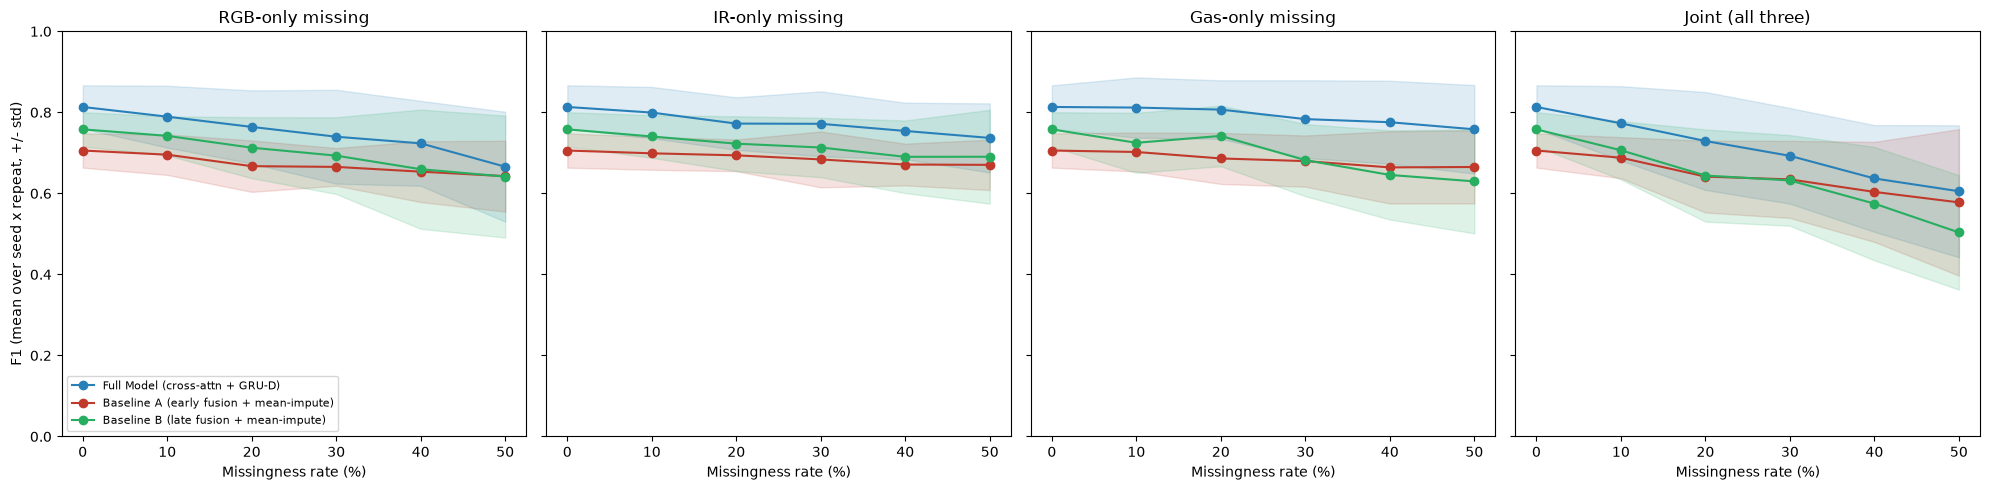

In [14]:
CONFIG_COLORS = {"full_model": "#2980b9", "baseline_a_early": "#c0392b", "baseline_b_late": "#27ae60"}

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
for ax, pattern in zip(axes, PATTERNS):
    for config_key in CONFIG_ORDER:
        sub = agg_df[(agg_df["config"] == config_key) & (agg_df["pattern"] == pattern)].sort_values("level")
        if sub.empty:
            continue
        x = sub["level"] * 100
        y = sub["f1_mean"]
        yerr = sub["f1_std"].fillna(0.0)
        color = CONFIG_COLORS[config_key]
        ax.plot(x, y, marker="o", color=color, label=CONFIG_LABELS[config_key])
        ax.fill_between(x, y - yerr, y + yerr, color=color, alpha=0.15)
    ax.set_title(PATTERN_LABELS[pattern])
    ax.set_xlabel("Missingness rate (%)")
    ax.set_ylim(0, 1.0)
axes[0].set_ylabel("F1 (mean over seed x repeat, +/- std)")
axes[0].legend(fontsize=8, loc="lower left")
plt.tight_layout()
plt.savefig(ROBUST_OUT / "fig_f1_vs_missingness.png", dpi=150)
plt.show()


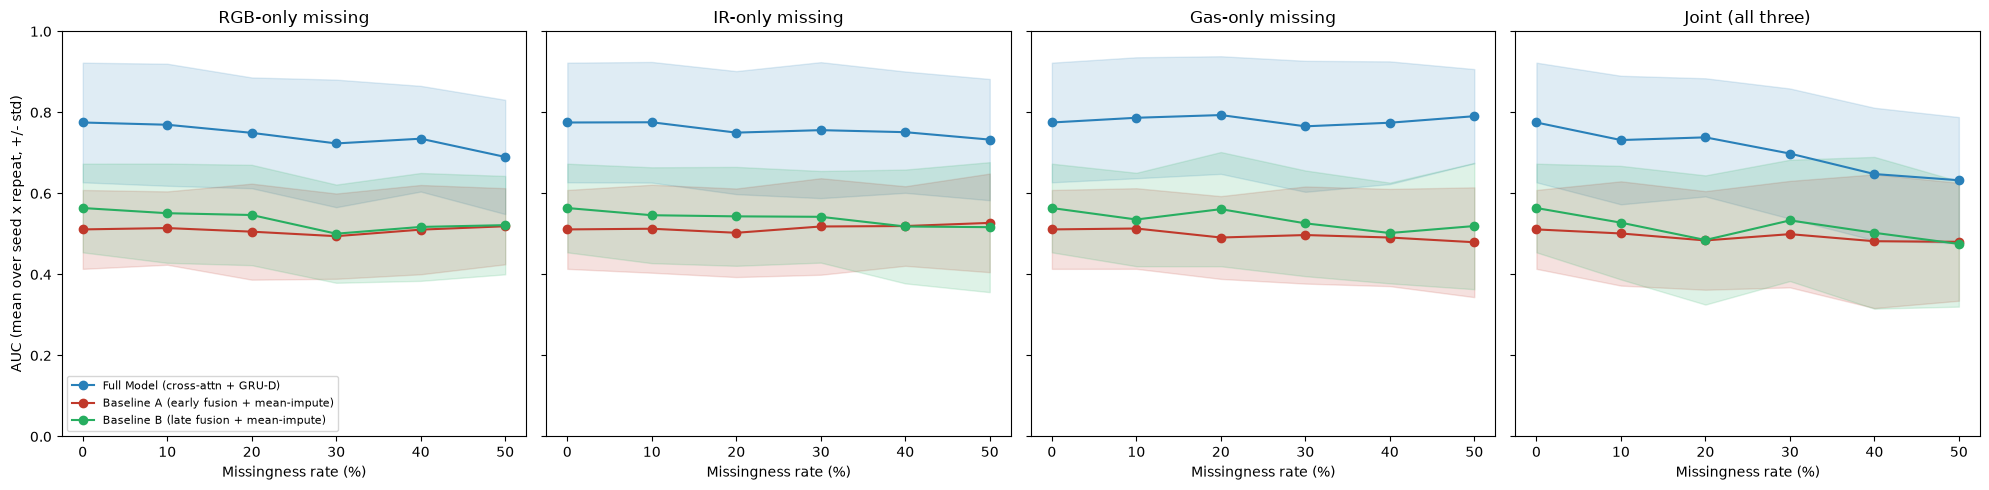

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
for ax, pattern in zip(axes, PATTERNS):
    for config_key in CONFIG_ORDER:
        sub = agg_df[(agg_df["config"] == config_key) & (agg_df["pattern"] == pattern)].sort_values("level")
        if sub.empty:
            continue
        x = sub["level"] * 100
        y = sub["auc_mean"]
        yerr = sub["auc_std"].fillna(0.0)
        color = CONFIG_COLORS[config_key]
        ax.plot(x, y, marker="o", color=color, label=CONFIG_LABELS[config_key])
        ax.fill_between(x, y - yerr, y + yerr, color=color, alpha=0.15)
    ax.set_title(PATTERN_LABELS[pattern])
    ax.set_xlabel("Missingness rate (%)")
    ax.set_ylim(0, 1.0)
axes[0].set_ylabel("AUC (mean over seed x repeat, +/- std)")
axes[0].legend(fontsize=8, loc="lower left")
plt.tight_layout()
plt.savefig(ROBUST_OUT / "fig_auc_vs_missingness.png", dpi=150)
plt.show()


## Sumamry

In [18]:
for pattern in PATTERNS:
    print(f"\n{PATTERN_LABELS[pattern]}")
    drops = {}
    for config_key in CONFIG_ORDER:
        sub = agg_df[(agg_df["config"] == config_key) & (agg_df["pattern"] == pattern)]
        f1_at_0 = sub[sub["level"] == 0.0]["f1_mean"]
        f1_at_50 = sub[sub["level"] == 0.50]["f1_mean"]
        if f1_at_0.empty or f1_at_50.empty:
            print(f"  {CONFIG_LABELS[config_key]}: insufficient data (see LOAD_FAILURES / SWEEP_FAILURES)")
            continue
        drop = float(f1_at_0.iloc[0] - f1_at_50.iloc[0])
        drops[config_key] = drop
        print(f"  {CONFIG_LABELS[config_key]}: F1 {f1_at_0.iloc[0]:.4f} -> {f1_at_50.iloc[0]:.4f} "
              f"(drop of {drop:+.4f})")

    if "full_model" in drops and drops:
        full_drop = drops["full_model"]
        baseline_drops = [d for k, d in drops.items() if k != "full_model"]
        if baseline_drops and full_drop < min(baseline_drops):
            print(f" Full Model degrades LESS than both baselines under {pattern} corruption: ")
        elif baseline_drops and full_drop > max(baseline_drops):
            print(f" Full Model degrades MORE than both baselines under {pattern} corruption: ")
        else:
            print(f"  Mixed: Full Model's degradation is between the two baselines' under {pattern} corruption")

print(f"\n\nFull results: {ROBUST_OUT / 'missing_data_sweep_raw.csv'}")
print(f"Aggregated: {ROBUST_OUT / 'missing_data_sweep_aggregated.csv'}")
if LOAD_FAILURES or SWEEP_FAILURES:
    print(f"\n{len(LOAD_FAILURES)} checkpoint load/train failure(s), "
          f"{len(SWEEP_FAILURES)} sweep-evaluation failure(s) ")



RGB-only missing
  Full Model (cross-attn + GRU-D): F1 0.8133 -> 0.6659 (drop of +0.1475)
  Baseline A (early fusion + mean-impute): F1 0.7058 -> 0.6426 (drop of +0.0633)
  Baseline B (late fusion + mean-impute): F1 0.7581 -> 0.6415 (drop of +0.1166)
 Full Model degrades MORE than both baselines under rgb corruption: 

IR-only missing
  Full Model (cross-attn + GRU-D): F1 0.8133 -> 0.7369 (drop of +0.0764)
  Baseline A (early fusion + mean-impute): F1 0.7058 -> 0.6705 (drop of +0.0354)
  Baseline B (late fusion + mean-impute): F1 0.7581 -> 0.6905 (drop of +0.0676)
 Full Model degrades MORE than both baselines under ir corruption: 

Gas-only missing
  Full Model (cross-attn + GRU-D): F1 0.8133 -> 0.7582 (drop of +0.0551)
  Baseline A (early fusion + mean-impute): F1 0.7058 -> 0.6652 (drop of +0.0407)
  Baseline B (late fusion + mean-impute): F1 0.7581 -> 0.6297 (drop of +0.1284)
  Mixed: Full Model's degradation is between the two baselines' under gas corruption

Joint (all three)
  Fu